# Preprocessing Pipeline — SSGI 2024 Stunting Risk Factors

This notebook executes the full data integration and standardization workflow for Fuzzy C-Means (FCM) clustering.

**Inputs**
- `data/interim/family_stunting_indicators.csv`
- `data/raw/water_access.csv`
- `data/raw/sanitation_access.csv`

**Outputs**
- `data/processed/fcm_risk_profile_2024.csv` (unstandardized)
- `data/processed/fcm_model_matrix_zscore.csv` (Z-score standardized)
- `data/processed/correlation_matrix.png`

In [2]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    OUTPUT_CORRELATION_PLOT,
    OUTPUT_RISK_PROFILE,
    OUTPUT_ZSCORE_MATRIX,
    export_csv,
    build_family_indicators,
    load_sanitation_access,
    load_water_access,
    merge_datasets,
    run_quality_checks,
    save_correlation_heatmap,
    standardize_fcm_features,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
print(f"Project root: {PROJECT_ROOT}")

Project root: c:\muti\SMT 6\PKK_PROJECT AKHIR\pkk-stunting-fcm-clustering


## 1. Load & Harmonize Source Datasets

Province names are stripped, uppercased, and the national `INDONESIA` aggregate row is removed.

In [3]:
family_df = build_family_indicators()
water_df = load_water_access()
sanitation_df = load_sanitation_access()

print(f"Family indicators: {len(family_df)} provinces")
print(f"Water access:      {len(water_df)} provinces")
print(f"Sanitation access: {len(sanitation_df)} provinces")

display(family_df.head(3))
display(water_df.head(3))
display(sanitation_df.head(3))

2026-06-29 12:41:25 | INFO | Loaded maternal_age.csv (37 rows, 5 columns)
2026-06-29 12:41:25 | INFO | Loaded stunting_knowledge.csv (37 rows, 3 columns)
2026-06-29 12:41:25 | INFO | Loaded stunting_prevalence.csv (37 rows, 5 columns)
2026-06-29 12:41:25 | INFO | Exported family_stunting_indicators.csv (37 rows)
2026-06-29 12:41:25 | INFO | Removed 1 national aggregate row(s) ('INDONESIA')
2026-06-29 12:41:25 | INFO | Loaded water_access.csv (37 rows, 5 columns)
2026-06-29 12:41:25 | INFO | Removed 1 national aggregate row(s) ('INDONESIA')
2026-06-29 12:41:25 | INFO | Loaded sanitation_access.csv (37 rows, 7 columns)
2026-06-29 12:41:25 | INFO | Removed 1 national aggregate row(s) ('INDONESIA')


Family indicators: 36 provinces
Water access:      36 provinces
Sanitation access: 36 provinces


,province_name,maternal_age_risk_pct,low_knowledge_pct,stunting_prevalence_pct,maternal_age_under21_pct,maternal_age_21_39_pct,maternal_age_over40_pct,knowledge_attitude_high_pct,severely_stunting_pct,stunting_pct,normal_height_for_age_pct
0,ACEH,9.40,99.70,28.60,4.50,90.00,4.90,0.30,6.40,22.20,71.40
1,BALI,12.50,99.70,8.60,8.30,87.30,4.20,0.30,1.50,7.10,91.30
2,BANGKA BELITUNG,13.00,99.60,20.10,8.80,86.90,4.20,0.40,3.40,16.70,79.90


,province_name,water_no_or_unimproved_pct,water_limited_pct
0,ACEH,8.00,1.20
1,SUMATERA UTARA,7.20,2.20
2,SUMATERA BARAT,9.60,2.40


,province_name,sanitation_babs_pct,sanitation_unimproved_pct
0,ACEH,6.20,5.20
1,SUMATERA UTARA,8.20,4.10
2,SUMATERA BARAT,20.50,6.00


## 2. Merge & Transform

Derived features:
- `water_no_or_unimproved_pct` = `water_no_access_pct` + `water_unimproved_pct`
- `sanitation_babs_pct` = `sanitation_open_babs_pct` + `sanitation_closed_babs_pct`

In [4]:
merged_df = merge_datasets(family_df, water_df, sanitation_df)
merged_df

2026-06-29 12:41:25 | INFO | Merged dataset: 36 provinces


,province_name,maternal_age_risk_pct,low_knowledge_pct,water_no_or_unimproved_pct,water_limited_pct,sanitation_babs_pct,sanitation_unimproved_pct,stunting_prevalence_pct
0,ACEH,9.40,99.70,8.00,1.20,6.20,5.20,28.60
1,BALI,12.50,99.70,1.60,2.00,0.60,2.60,8.60
2,BANGKA BELITUNG,13.00,99.60,17.50,0.70,1.20,1.90,20.10
3,BANTEN,10.80,99.60,3.00,0.70,6.40,3.90,21.10
4,BENGKULU,13.30,99.50,9.80,0.40,3.30,3.00,18.80
5,DI YOGYAKARTA,9.60,97.80,4.40,0.30,2.20,1.60,17.40
6,DKI JAKARTA,9.40,99.30,0.50,0.10,9.20,3.10,17.20
7,GORONTALO,17.40,100.00,10.90,3.50,4.60,10.40,23.90
8,JAMBI,11.40,98.60,7.30,1.30,4.90,4.30,17.10
9,JAWA BARAT,12.40,98.90,4.10,2.80,15.00,5.00,15.90


## 3. Data Quality Checks

Missing values are reported (not imputed with zero). Outliers are flagged via IQR and Z-score methods.

In [5]:
quality_report = run_quality_checks(merged_df)

print("Missing values:")
display(quality_report["missing"])

print("\nIQR outliers:")
display(quality_report["outliers_iqr"])

print("\nZ-score outliers:")
display(quality_report["outliers_zscore"])

2026-06-29 12:41:26 | INFO | --- Data quality checks ---
2026-06-29 12:41:26 | INFO | Missing values: none detected in target columns.
2026-06-29 12:41:26 | WARNING | IQR outliers flagged (11):
      province_name                    feature  value method  lower_bound  upper_bound
      DI YOGYAKARTA          low_knowledge_pct  97.80    IQR        97.89       100.79
        JAWA TENGAH          low_knowledge_pct  91.80    IQR        97.89       100.79
              PAPUA          low_knowledge_pct  96.10    IQR        97.89       100.79
   PAPUA BARAT DAYA water_no_or_unimproved_pct  25.50    IQR        -6.06        23.04
      PAPUA SELATAN water_no_or_unimproved_pct  26.80    IQR        -6.06        23.04
NUSA TENGGARA TIMUR          water_limited_pct  12.50    IQR        -2.93         8.28
  SULAWESI TENGGARA          water_limited_pct  11.70    IQR        -2.93         8.28
         JAWA BARAT        sanitation_babs_pct  15.00    IQR        -1.30        12.50
      PAPUA SELATAN    

Missing values:


,missing_count



IQR outliers:


,province_name,feature,value,method,lower_bound,upper_bound
0,DI YOGYAKARTA,low_knowledge_pct,97.80,IQR,97.89,100.79
1,JAWA TENGAH,low_knowledge_pct,91.80,IQR,97.89,100.79
2,PAPUA,low_knowledge_pct,96.10,IQR,97.89,100.79
3,PAPUA BARAT DAYA,water_no_or_unimproved_pct,25.50,IQR,-6.06,23.04
4,PAPUA SELATAN,water_no_or_unimproved_pct,26.80,IQR,-6.06,23.04
5,NUSA TENGGARA TIMUR,water_limited_pct,12.50,IQR,-2.93,8.28
6,SULAWESI TENGGARA,water_limited_pct,11.70,IQR,-2.93,8.28
7,JAWA BARAT,sanitation_babs_pct,15.00,IQR,-1.30,12.50
8,PAPUA SELATAN,sanitation_babs_pct,15.80,IQR,-1.30,12.50
9,SUMATERA BARAT,sanitation_babs_pct,20.50,IQR,-1.30,12.50



Z-score outliers:


,province_name,feature,value,method,z_score,threshold
0,JAWA TENGAH,low_knowledge_pct,91.80,Z-score,-5.11,3.00
1,NUSA TENGGARA TIMUR,water_limited_pct,12.50,Z-score,3.11,3.00
2,SUMATERA BARAT,sanitation_babs_pct,20.50,Z-score,3.49,3.00
3,NUSA TENGGARA TIMUR,sanitation_unimproved_pct,27.90,Z-score,4.36,3.00


## 4. Correlation Matrix Heatmap

2026-06-29 12:41:26 | INFO | Correlation heatmap saved to C:\muti\SMT 6\PKK_PROJECT AKHIR\pkk-stunting-fcm-clustering\data\processed\correlation_matrix.png


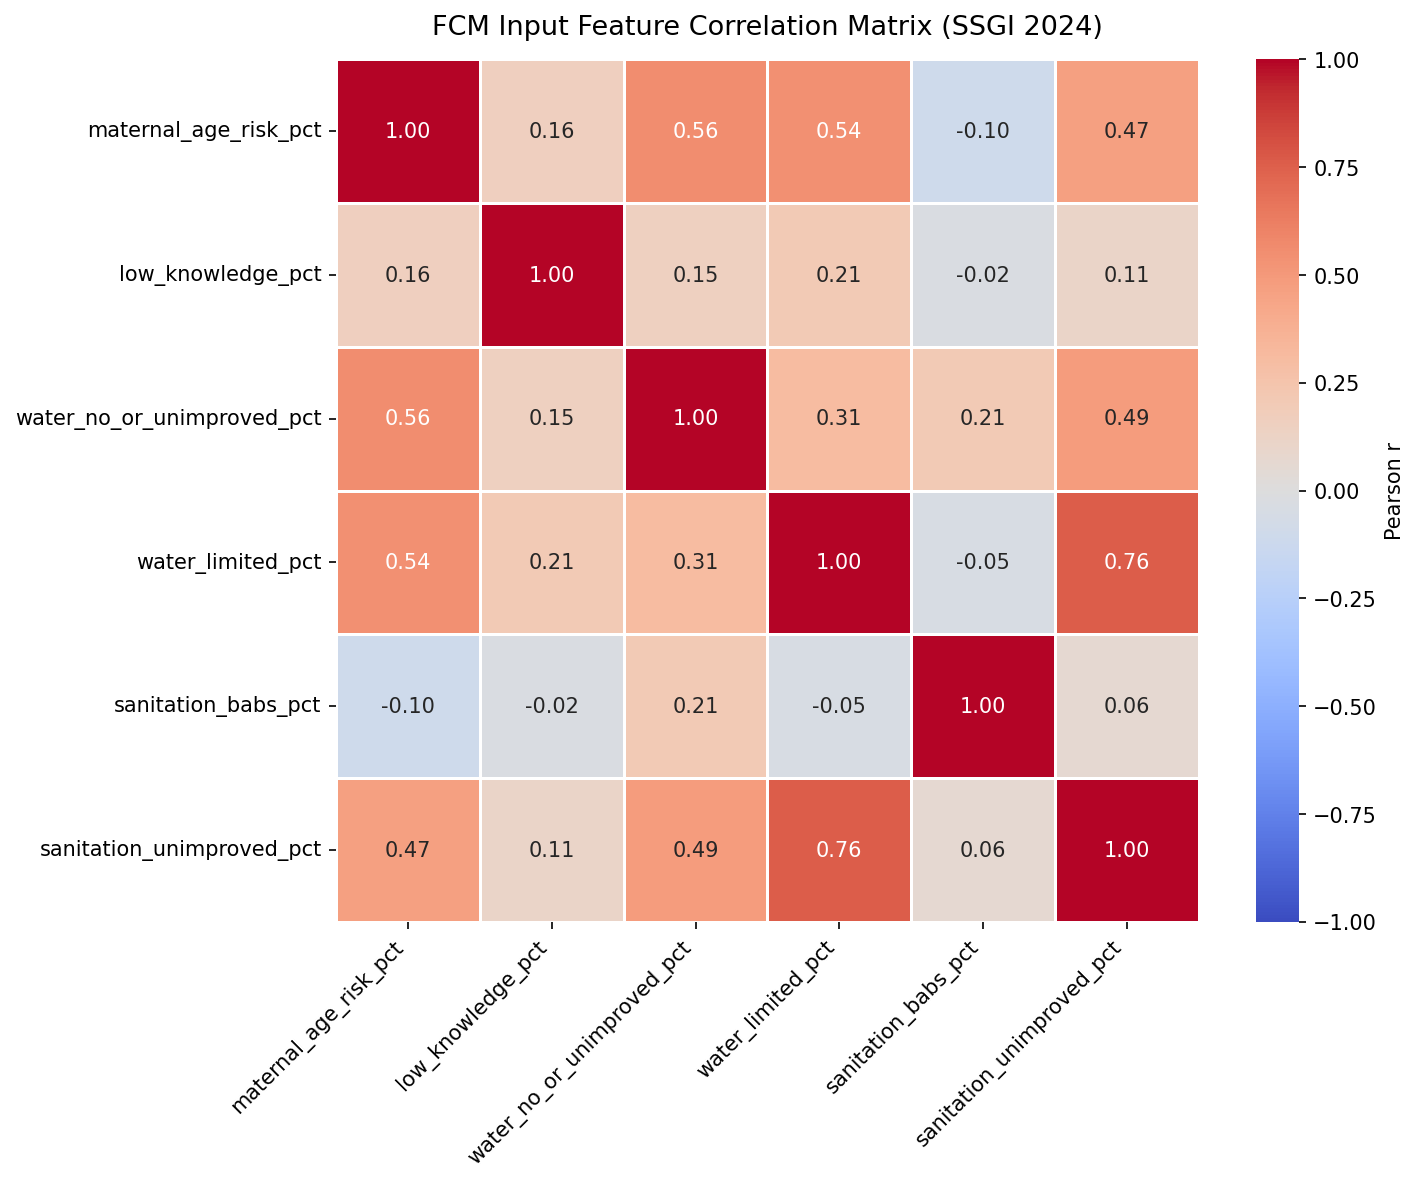

In [6]:
from IPython.display import Image, display

save_correlation_heatmap(merged_df, OUTPUT_CORRELATION_PLOT)
display(Image(filename=str(OUTPUT_CORRELATION_PLOT)))

## 5. Z-Score Standardization (6 FCM Features)

`stunting_prevalence_pct` is retained only in the unstandardized output for post-clustering validation.

In [7]:
zscore_df = standardize_fcm_features(merged_df)
zscore_df.describe()

,maternal_age_risk_z,low_knowledge_z,water_no_or_unimproved_z,water_limited_z,sanitation_babs_z,sanitation_unimproved_z
count,36.00,36.00,36.00,36.00,36.00,36.00
mean,-0.00,0.00,0.00,-0.00,0.00,0.00
std,1.01,1.01,1.01,1.01,1.01,1.01
min,-1.50,-5.11,-1.41,-1.09,-1.35,-1.14
25%,-0.91,-0.08,-0.70,-0.70,-0.55,-0.62
50%,-0.21,0.33,-0.25,-0.20,-0.23,-0.25
75%,0.79,0.43,0.48,0.25,0.29,0.36
max,1.69,0.64,2.86,3.11,3.49,4.36


## 6. Export Processed Files

In [8]:
export_csv(merged_df, OUTPUT_RISK_PROFILE)
export_csv(zscore_df, OUTPUT_ZSCORE_MATRIX)

print(f"Unstandardized: {OUTPUT_RISK_PROFILE} ({len(merged_df)} rows)")
print(f"Z-score matrix: {OUTPUT_ZSCORE_MATRIX} ({len(zscore_df)} rows)")
print(f"Correlation plot: {OUTPUT_CORRELATION_PLOT}")

2026-06-29 12:41:26 | INFO | Exported fcm_risk_profile_2024.csv (36 rows)
2026-06-29 12:41:26 | INFO | Exported fcm_model_matrix_zscore.csv (36 rows)


Unstandardized: C:\muti\SMT 6\PKK_PROJECT AKHIR\pkk-stunting-fcm-clustering\data\processed\fcm_risk_profile_2024.csv (36 rows)
Z-score matrix: C:\muti\SMT 6\PKK_PROJECT AKHIR\pkk-stunting-fcm-clustering\data\processed\fcm_model_matrix_zscore.csv (36 rows)
Correlation plot: C:\muti\SMT 6\PKK_PROJECT AKHIR\pkk-stunting-fcm-clustering\data\processed\correlation_matrix.png
